In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

sns.set(style="whitegrid")

In [14]:
def clean_climate_data(path, country_name):
    df = pd.read_csv(path)
    df["Country"] = country_name
    df.replace(-999, np.nan, inplace=True)
    df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
    df["Month"] = df["DATE"].dt.month
    df = df.drop_duplicates()
    df = df.ffill()    
    cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
    z = np.abs(df[cols].apply(zscore))
    outliers = (z > 3).sum()

    print(f"{country_name} outliers:\n", outliers)

    return df

In [15]:
ethiopia = clean_climate_data("../Data/ethiopia.csv", "Ethiopia")
kenya = clean_climate_data("../Data/kenya.csv", "Kenya")
nigeria = clean_climate_data("../Data/nigeria.csv", "Nigeria")
tanzania = clean_climate_data("../Data/tanzania.csv", "Tanzania")
sudan = clean_climate_data("../Data/sudan.csv", "Sudan")

Ethiopia outliers:
 T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64
Kenya outliers:
 T2M             8
T2M_MAX         3
T2M_MIN         9
PRECTOTCORR    92
RH2M            6
WS2M            0
WS2M_MAX        6
dtype: int64
Nigeria outliers:
 T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64
Tanzania outliers:
 T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64
Sudan outliers:
 T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


In [17]:
ethiopia.to_csv("../Data/ethiopia_clean.csv", index=False)
kenya.to_csv("../Data/kenya_clean.csv", index=False)
nigeria.to_csv("../Data/nigeria_clean.csv", index=False)
tanzania.to_csv("../Data/tanzania_clean.csv", index=False)
sudan.to_csv("../Data/sudan_clean.csv", index=False)

In [18]:
df = pd.concat([ethiopia, kenya, nigeria, tanzania, sudan], ignore_index=True)

<Axes: xlabel='Country'>

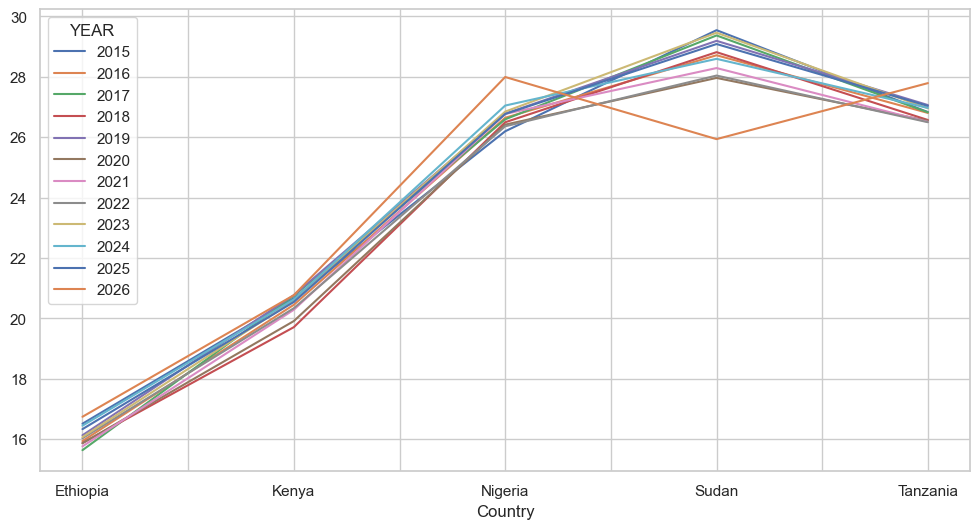

In [20]:
df.groupby(["Country", "YEAR"])["T2M"].mean().unstack().plot(figsize=(12,6))

<Axes: xlabel='Country', ylabel='PRECTOTCORR'>

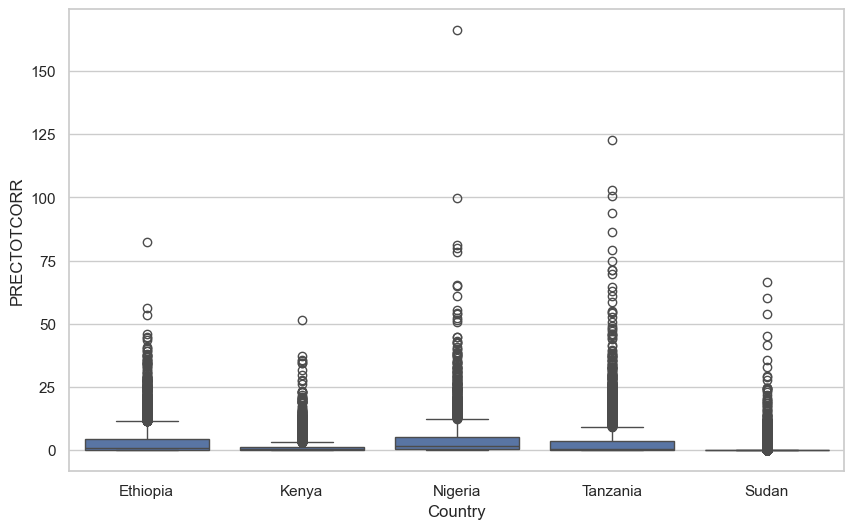

In [21]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)

<Axes: xlabel='Country'>

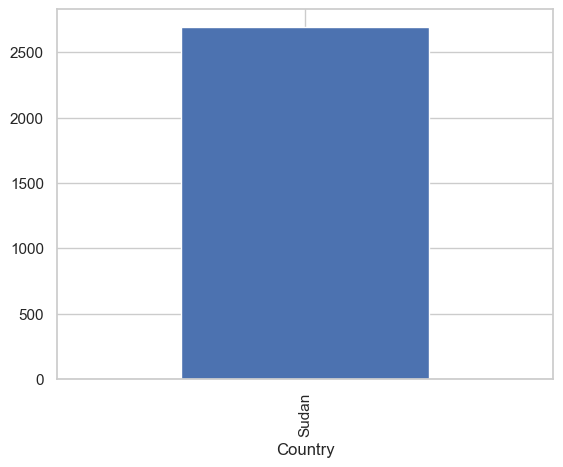

In [22]:
df[df["T2M_MAX"] > 35].groupby("Country").size().plot(kind="bar")

<Axes: xlabel='Country'>

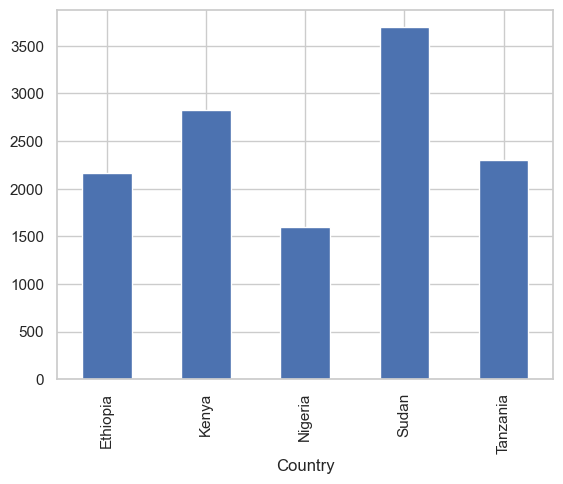

In [23]:
df[df["PRECTOTCORR"] < 1].groupby("Country").size().plot(kind="bar")

In [24]:
heat = df[df["T2M_MAX"] > 35].groupby("Country").size()
dry = df[df["PRECTOTCORR"] < 1].groupby("Country").size()
rain_var = df.groupby("Country")["PRECTOTCORR"].std()

ranking = pd.DataFrame({
    "Heat": heat,
    "Dry": dry,
    "Rain_Variability": rain_var
}).fillna(0)

ranking["Score"] = ranking.sum(axis=1)
ranking = ranking.sort_values("Score", ascending=False)

print(ranking)

            Heat   Dry  Rain_Variability        Score
Country                                              
Sudan     2694.0  3696          3.057672  6393.057672
Kenya        0.0  2831          3.180228  2834.180228
Tanzania     0.0  2303          8.003947  2311.003947
Ethiopia     0.0  2161          6.289061  2167.289061
Nigeria      0.0  1595          7.266742  1602.266742
